In [4]:
%pip install matplotlib numpy scipy pandas requests

  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached numpy-2.4.4-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached pandas-3.0.2-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
Using cached numpy-2.4.4-cp314-cp314-macosx_14_0_arm64.whl (5.2 MB)
Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl (20.3 MB)

  Hour 8: 6236 ticks
  Hour 9: 4795 ticks
  Hour 10: 5753 ticks
  Hour 11: 4814 ticks
  Hour 12: 4510 ticks
  Hour 13: 6759 ticks
  Total: 32867 ticks | span: 6.00 hrs | rate: 1.522 ticks/sec

  Hour 8: 25196 ticks
  Hour 9: 15755 ticks
  Hour 10: 17113 ticks
  Hour 11: 15151 ticks
  Hour 12: 25736 ticks
  Hour 13: 27129 ticks
  Total: 126080 ticks | span: 6.00 hrs | rate: 5.837 ticks/sec

Combined dataset: 158947 ticks


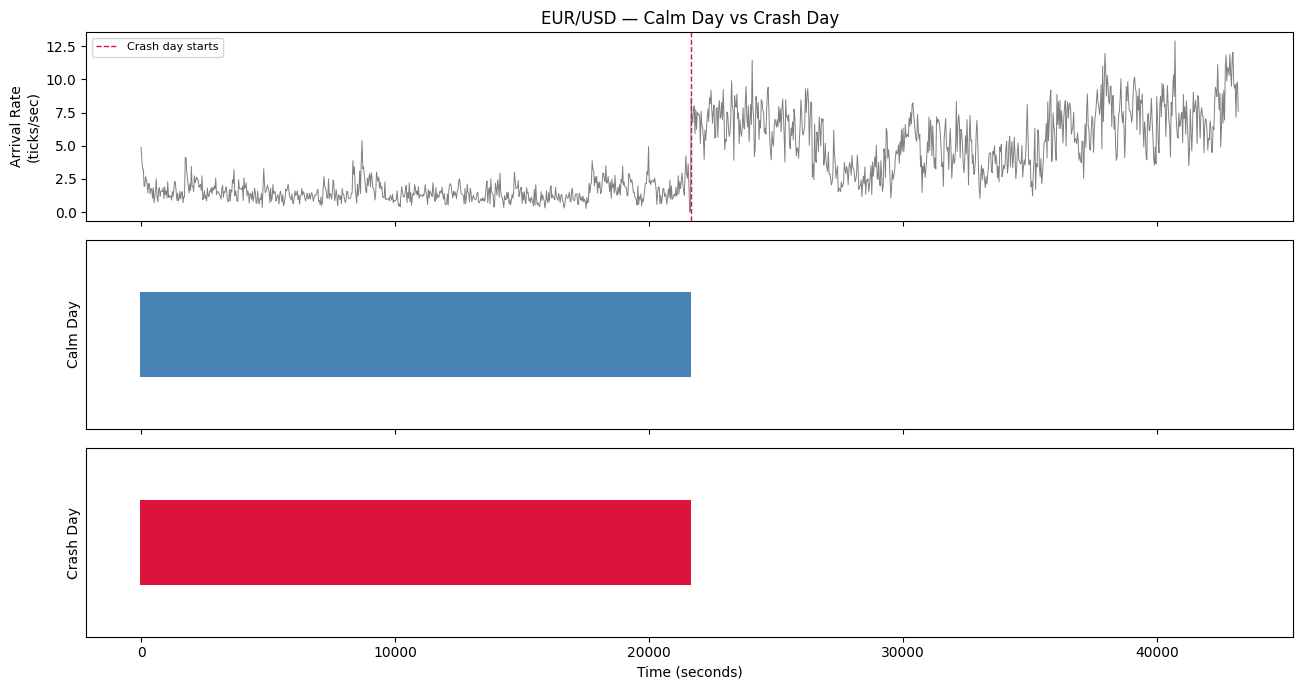

In [11]:
import requests
import struct
import lzma
import numpy as np
import matplotlib.pyplot as plt
import time

def download_dukascopy_ticks(year, month, day, hour, retries=3, timeout=30):
    month_str = str(month - 1).zfill(2)
    url = (f"https://datafeed.dukascopy.com/datafeed/EURUSD/"
           f"{year}/{month_str}/{str(day).zfill(2)}/"
           f"{str(hour).zfill(2)}h_ticks.bi5")
    
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
        "Referer": "https://www.dukascopy.com/",
        "Accept-Encoding": "gzip, deflate, br"
    }
    
    for attempt in range(retries):
        try:
            r = requests.get(url, headers=headers, timeout=timeout)
            if r.status_code == 200 and len(r.content) > 10:
                raw = lzma.decompress(r.content)
                ticks = []
                record_size = 20
                for i in range(0, len(raw), record_size):
                    chunk = raw[i:i+record_size]
                    if len(chunk) < record_size:
                        break
                    ms, ask, bid, ask_vol, bid_vol = struct.unpack(">IIIff", chunk)
                    ticks.append(ms)
                return ticks
            else:
                print(f"    Hour {hour}: empty response (status {r.status_code})")
                return None
        except Exception as e:
            print(f"    Attempt {attempt+1} failed: {e}")
            time.sleep(2)
    return None

def fetch_day(year, month, day, hours=range(8,14), label=""):
    print(f"Downloading {label}...")
    all_ts = []
    for hour in hours:
        ticks = download_dukascopy_ticks(year, month, day, hour)
        if ticks:
            base = hour * 3600
            all_ts.extend([base + ms/1000.0 for ms in ticks])
            print(f"  Hour {hour}: {len(ticks)} ticks")
        else:
            print(f"  Hour {hour}: skipped")
    ts = np.array(sorted(all_ts))
    ts = ts - ts[0]
    print(f"  Total: {len(ts)} ticks | span: {ts[-1]/3600:.2f} hrs | rate: {len(ts)/ts[-1]:.3f} ticks/sec\n")
    return ts

# Calm day: January 7 2020 (quiet pre-COVID Tuesday)
timestamps_quiet = fetch_day(2020, 1, 7,  label="Calm Day  — Jan 07 2020")

# Crash day: March 16 2020 (COVID crash)
timestamps_crash = fetch_day(2020, 3, 16, label="Crash Day — Mar 16 2020")

# Combined: offset crash day so it follows calm day in time
offset = timestamps_quiet[-1] + 60
timestamps_combined = np.concatenate([timestamps_quiet, timestamps_crash + offset])
day_labels = np.array(['Calm']*len(timestamps_quiet) + ['Crash']*len(timestamps_crash))

print(f"Combined dataset: {len(timestamps_combined)} ticks")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)

window_sec = 30
bins   = np.arange(timestamps_combined[0], timestamps_combined[-1], window_sec)
counts, _ = np.histogram(timestamps_combined, bins=bins)
axes[0].plot(bins[:-1], counts/window_sec, color='gray', linewidth=0.7)
axes[0].axvline(offset, color='crimson', linestyle='--', linewidth=1, label='Crash day starts')
axes[0].set_ylabel("Arrival Rate\n(ticks/sec)")
axes[0].set_title("EUR/USD — Calm Day vs Crash Day")
axes[0].legend(fontsize=8)

axes[1].eventplot(timestamps_quiet, linewidths=0.3, color='steelblue')
axes[1].set_ylabel("Calm Day")
axes[1].set_yticks([])

axes[2].eventplot(timestamps_crash, linewidths=0.3, color='crimson')
axes[2].set_ylabel("Crash Day")
axes[2].set_yticks([])
axes[2].set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()

Fitting Hawkes parameters via MLE...

Fitted Parameters:
  mu    = 1.0049 events/sec  (baseline rate)
  alpha = 0.7049           (excitation jump)
  beta  = 0.8767           (decay rate)
  n     = alpha/beta = 0.8040  (branching ratio)

Converged: True | LL = 54267.43

Computing intensity curve for plot...


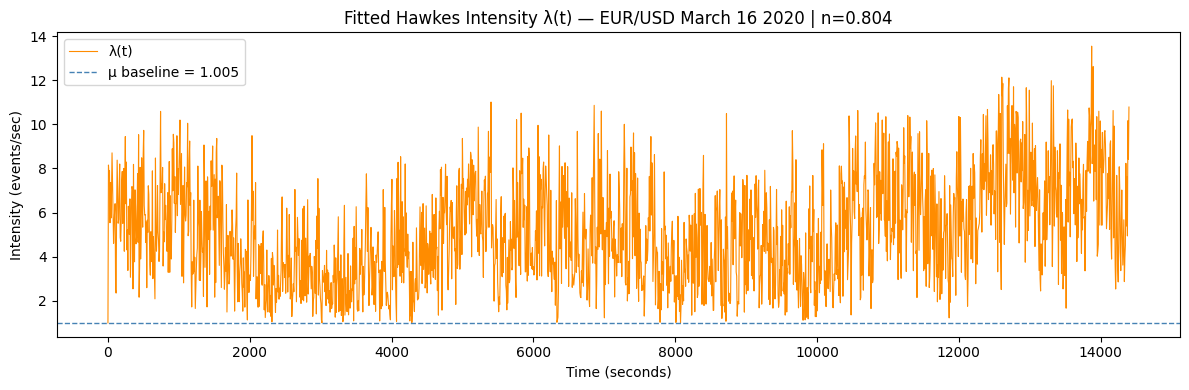

In [12]:
from scipy.optimize import minimize
from scipy.stats import kstest, expon

def hawkes_log_likelihood(params, timestamps, T):
    mu, alpha, beta = params
    if mu <= 0 or alpha <= 0 or beta <= 0 or alpha >= beta:
        return np.inf
    
    n = len(timestamps)
    
    # Recursive intensity computation
    lambdas = []
    R = 0.0  # recursive sum
    for i in range(n):
        if i == 0:
            R = 0.0
        else:
            R = np.exp(-beta * (timestamps[i] - timestamps[i-1])) * (1 + R)
        lam = mu + alpha * R
        lambdas.append(lam)
    
    # Log-likelihood terms
    log_sum = np.sum(np.log(lambdas))
    
    # Compensator integral
    compensator = mu * T + (alpha / beta) * np.sum(1 - np.exp(-beta * (T - timestamps)))
    
    return -(log_sum - compensator)

T = timestamps[-1]

# Initial guess
x0 = [2.0, 1.0, 2.0]
bounds = [(1e-4, None), (1e-4, None), (1e-4, None)]

print("Fitting Hawkes parameters via MLE...")
result = minimize(hawkes_log_likelihood, x0, args=(timestamps, T),
                  method='L-BFGS-B', bounds=bounds,
                  options={'maxiter': 1000, 'ftol': 1e-12})

mu_fit, alpha_fit, beta_fit = result.x
n_fit = alpha_fit / beta_fit

print(f"\nFitted Parameters:")
print(f"  mu    = {mu_fit:.4f} events/sec  (baseline rate)")
print(f"  alpha = {alpha_fit:.4f}           (excitation jump)")
print(f"  beta  = {beta_fit:.4f}           (decay rate)")
print(f"  n     = alpha/beta = {n_fit:.4f}  (branching ratio)")
print(f"\nConverged: {result.success} | LL = {-result.fun:.2f}")

# Compute lambda(t) over time using recursive formula
def compute_intensity(timestamps, mu, alpha, beta, t_grid):
    intensities = []
    for t in t_grid:
        past = timestamps[timestamps < t]
        lam = mu + alpha * np.sum(np.exp(-beta * (t - past)))
        intensities.append(lam)
    return np.array(intensities)

# Sample 2000 points for plotting (full computation is slow)
t_grid = np.linspace(timestamps[0], timestamps[-1], 2000)
print("\nComputing intensity curve for plot...")
lambdas_plot = compute_intensity(timestamps, mu_fit, alpha_fit, beta_fit, t_grid)

plt.figure(figsize=(12, 4))
plt.plot(t_grid, lambdas_plot, color='darkorange', linewidth=0.8, label='λ(t)')
plt.axhline(mu_fit, color='steelblue', linestyle='--', linewidth=1, label=f'µ baseline = {mu_fit:.3f}')
plt.title(f"Fitted Hawkes Intensity λ(t) — EUR/USD March 16 2020 | n={n_fit:.3f}")
plt.xlabel("Time (seconds)")
plt.ylabel("Intensity (events/sec)")
plt.legend()
plt.tight_layout()
plt.show()

Computing compensators (this takes ~30 sec)...

── Time-Rescaling KS Test ──
  KS statistic : 0.1844
  p-value      : 0.0000
  Result       : FAIL ✗

── Branching Ratio Check ──
  n = alpha/beta = 0.8040
  Result: PASS ✓  (within empirical range 0.5–0.99)

── AIC / BIC Comparison ──
  Model           k       LogLik          AIC          BIC
  Hawkes          3     54267.43   -108528.87   -108501.24
  Poisson         1     46726.08    -93450.17    -93440.96
  Result: Hawkes wins ✓


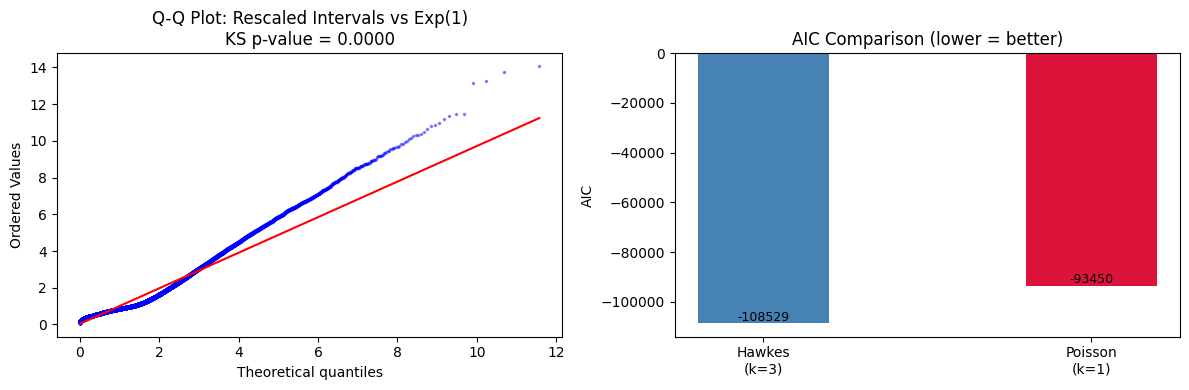

In [13]:
from scipy.stats import kstest, expon

# ── 1. Time-Rescaling Theorem ──────────────────────────────────────────────
# Compensator: Λ(t_i) = integral of lambda from 0 to t_i
# Rescaled intervals should be iid Exp(1)

def compute_compensator(timestamps, mu, alpha, beta):
    compensators = []
    for i in range(len(timestamps)):
        t_i = timestamps[i]
        # Integral of mu from 0 to t_i
        comp = mu * t_i
        # Integral of self-exciting part
        past = timestamps[:i]
        comp += (alpha / beta) * np.sum(1 - np.exp(-beta * (t_i - past)))
        compensators.append(comp)
    return np.array(compensators)

print("Computing compensators (this takes ~30 sec)...")
compensators = compute_compensator(timestamps, mu_fit, alpha_fit, beta_fit)

# Rescaled inter-arrival times
rescaled = np.diff(compensators)
rescaled = rescaled[rescaled > 0]

# KS test against Exp(1)
ks_stat, ks_pval = kstest(rescaled, 'expon', args=(0, 1))
print(f"\n── Time-Rescaling KS Test ──")
print(f"  KS statistic : {ks_stat:.4f}")
print(f"  p-value      : {ks_pval:.4f}")
print(f"  Result       : {'PASS ✓' if ks_pval > 0.05 else 'FAIL ✗'}")

# ── 2. Branching Ratio Check ───────────────────────────────────────────────
print(f"\n── Branching Ratio Check ──")
print(f"  n = alpha/beta = {n_fit:.4f}")
if 0.5 <= n_fit <= 0.99:
    print(f"  Result: PASS ✓  (within empirical range 0.5–0.99)")
elif n_fit < 0.5:
    print(f"  Result: WARNING — low excitation, nearly Poisson")
else:
    print(f"  Result: FAIL ✗  — explosive process (n >= 1)")

# ── 3. AIC/BIC vs Poisson ─────────────────────────────────────────────────
n_events = len(timestamps)
T = timestamps[-1]

# Hawkes log-likelihood (already fitted)
ll_hawkes = -result.fun

# Poisson MLE: mu_poisson = N/T
mu_poisson = n_events / T
ll_poisson = n_events * np.log(mu_poisson) - mu_poisson * T

# AIC = 2k - 2LL, BIC = k*ln(N) - 2LL
aic_hawkes  = 2*3 - 2*ll_hawkes
aic_poisson = 2*1 - 2*ll_poisson
bic_hawkes  = 3*np.log(n_events) - 2*ll_hawkes
bic_poisson = 1*np.log(n_events) - 2*ll_poisson

print(f"\n── AIC / BIC Comparison ──")
print(f"  {'Model':<12} {'k':>4} {'LogLik':>12} {'AIC':>12} {'BIC':>12}")
print(f"  {'Hawkes':<12} {'3':>4} {ll_hawkes:>12.2f} {aic_hawkes:>12.2f} {bic_hawkes:>12.2f}")
print(f"  {'Poisson':<12} {'1':>4} {ll_poisson:>12.2f} {aic_poisson:>12.2f} {bic_poisson:>12.2f}")
print(f"  Result: {'Hawkes wins ✓' if aic_hawkes < aic_poisson else 'Poisson wins ✗'}")

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# QQ plot of rescaled intervals vs Exp(1)
from scipy.stats import probplot
probplot(rescaled, dist=expon, plot=axes[0])
axes[0].set_title(f"Q-Q Plot: Rescaled Intervals vs Exp(1)\nKS p-value = {ks_pval:.4f}")
axes[0].get_lines()[0].set(markersize=1.5, alpha=0.4)

# AIC comparison bar
models = ['Hawkes\n(k=3)', 'Poisson\n(k=1)']
aics = [aic_hawkes, aic_poisson]
colors = ['steelblue', 'crimson']
axes[1].bar(models, aics, color=colors, width=0.4)
axes[1].set_title("AIC Comparison (lower = better)")
axes[1].set_ylabel("AIC")
for i, v in enumerate(aics):
    axes[1].text(i, v + abs(v)*0.01, f"{v:.0f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Fitting MLE on each window (~234 windows)...


/Users/rishavsingh/Desktop/Hawkes Process/venv10/lib/python3.14/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


  20/234 windows done...
  40/234 windows done...
  60/234 windows done...
  80/234 windows done...
  100/234 windows done...
  120/234 windows done...
  140/234 windows done...
  160/234 windows done...
  180/234 windows done...
  200/234 windows done...
  220/234 windows done...

Total windows classified: 235
  Quiet: 0 windows (0.0%)
  Trending: 113 windows (48.1%)
  Crash: 122 windows (51.9%)


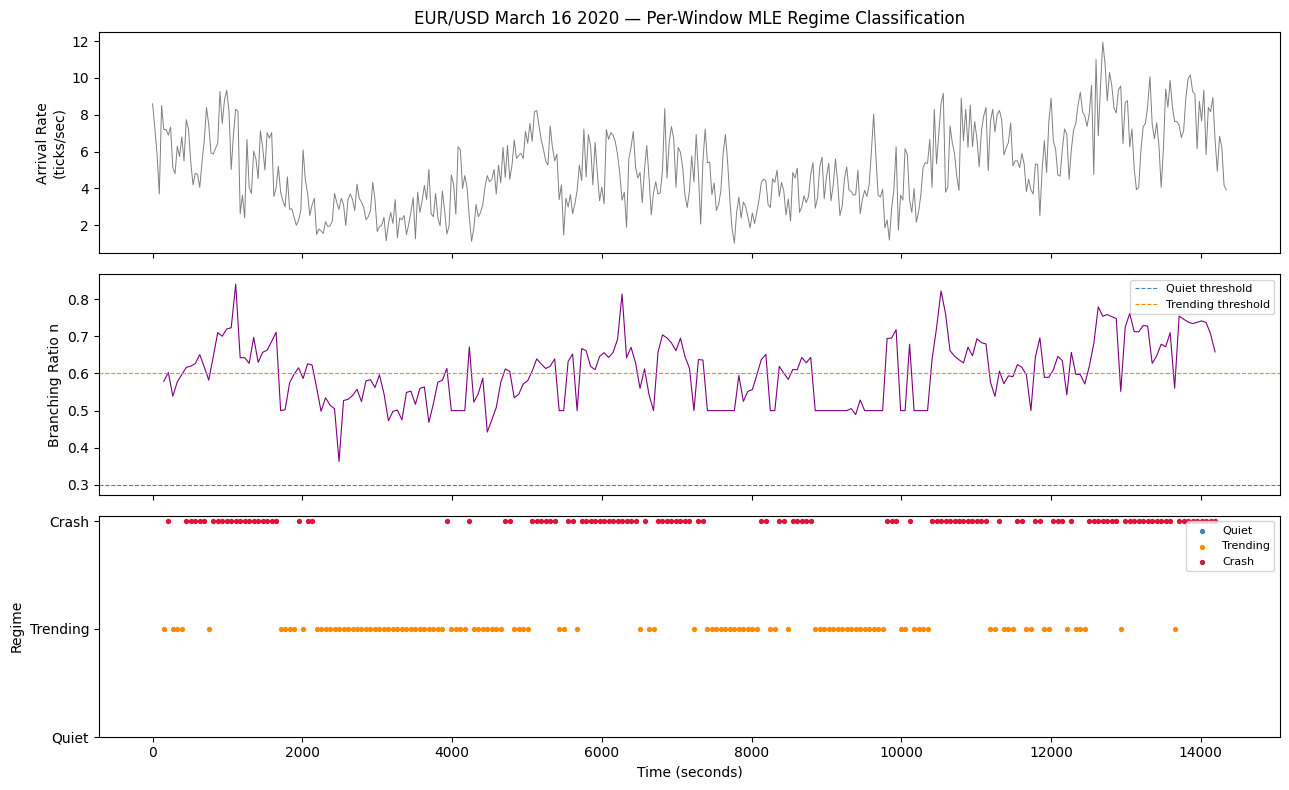